# Patch-based stratification on natural images

Each `3x3` patch of a grayscale image (after per-patch mean subtraction)
is a point in `R^9`. Flat regions concentrate near the origin, edges live
on low dimensional submanifolds, and textured regions fill
higher dimensional neighbourhoods. We PCA-reduce the patches and build a two-parameter filtration on the reduced
cloud:

`f_1` is Euclidean distance (proximity in patch space)

`f_2` is local-PCA intrinsic-dimension difference `|dim(i) − dim(j)|` with a connectivity penalty (stratum identity).

Slicing the bifiltration with y = a * x gives a single-linkage tree, which we simplify to three classes via `simplified_labels`. A small `min_size` sweep picks the cut with the best (balance * dim-spread) score.


Clusters are labelled by mean intrinsic dimension: flat / edge / texture. Other  methods: `Dim + Otsu(gradient)` hierarchical split, `KMeans`, and `Ward` on raw PCA patches.

Source images: `data/house.png`, `data/tissue.png`

In [1]:
from pathlib import Path                                                                                                                                                                                            
from dataclasses import dataclass                                                                                                                                                                                 
                                                                                                                                                                                                                    
import numpy as np                
import matplotlib.pyplot as plt                                                                                                                                                                                     
from matplotlib.colors import ListedColormap                                                                                                                                                                        
from scipy.ndimage import sobel   
from scipy.spatial.distance import cdist                                                                                                                                                                            
from skimage import color, filters, io as skio
from sklearn.cluster import AgglomerativeClustering, KMeans                                                                                                                                                         
from sklearn.decomposition import PCA
from sklearn.feature_extraction.image import extract_patches_2d                                                                                                                                                     
                                                                                                                                                                                                                    
from mpc.bifiltration_processor import BifiltrationProcessor
from mpc.clustering_utils import ClusteringUtils                                                                                                                                                                    
from mpc.filtration_builder import FiltrationBuilder
from mpc.pipeline import normalize_filtration                                                                                                                                                                       
                                                                                                                                                                                                                
FIG = Path("figures")                                                                                                                                                                                               
FIG.mkdir(exist_ok=True)                                                                                                                                                                                          
DATA = Path("data")      

In [2]:
def load_grayscale(path):
    img = skio.imread(path)
    if img.ndim == 3:
        img = color.rgb2gray(img[:, :, :3] if img.shape[2] == 4 else img)
    elif img.max() > 1:
        img = img.astype(float) / 255.0
    return img.astype(float)


def _order_by_dim(labels, dims_ref):
    order = sorted(np.unique(labels), key=lambda c: dims_ref[labels == c].mean())
    remap = {old: new for new, old in enumerate(order)}
    return np.array([remap[l] for l in labels])


def _pcts_dims(lab, dims):
    uniq = np.unique(lab)
    pcts = "/".join(f"{100*(lab==u).sum()/len(lab):.0f}" for u in uniq)
    dms = "/".join(f"{dims[lab==u].mean():.1f}" for u in uniq)
    return pcts, dms

In [3]:
@dataclass
class PatchConfig:
    name: str
    pca_dim: int
    k_nb: int = 5
    slice_angle: float = 1.0
    bif_sample: int = 500
    k_mle: int = 15
    flat_percentile: float = 15.0
    n_classes: int = 3
    seed: int = 42


SIMPLIFY_SIZES = [5, 8, 10, 15, 20, 30, 50, 75]


def _score_split(lab, dims_ref, target_k):
    uniq = np.unique(lab)
    if len(uniq) < 2:
        return -np.inf
    sizes = np.array([np.sum(lab == c) for c in uniq])
    dm = np.array([dims_ref[lab == c].mean() for c in uniq])
    balance = sizes.min() / sizes.max()
    spread = dm.max() - dm.min()
    k_match = 1000.0 if len(uniq) == target_k else 0.0
    return k_match + balance * spread


def _prep(img, cfg):
    rows, cols = img.shape
    X_all = extract_patches_2d(img, (3, 3)).reshape(-1, 9).astype(float)
    X_all -= X_all.mean(axis=1, keepdims=True)
    pr = np.repeat(np.arange(1, rows - 1), cols - 2)
    pc = np.tile(np.arange(1, cols - 1), rows - 2)

    rng = np.random.RandomState(cfg.seed)
    bif_n = min(cfg.bif_sample, len(X_all))
    i_bif = rng.choice(len(X_all), bif_n, replace=False)
    X_bif_raw = X_all[i_bif]
    dims_bif = FiltrationBuilder.estimate_local_dim_mle(
        X_bif_raw, k=cfg.k_mle, flat_percentile=cfg.flat_percentile,
    )
    pca = PCA(n_components=cfg.pca_dim, random_state=cfg.seed).fit(X_bif_raw)
    return {
        "rows": rows, "cols": cols, "pr": pr, "pc": pc,
        "i_bif": i_bif, "X_bif": pca.transform(X_bif_raw),
        "X_all_pca": pca.transform(X_all),
        "dims_bif": dims_bif, "pca": pca,
    }


def _default_pair(fb, cfg):
    return (
        fb.get_filtration_from_scipy_dist("euclidean"),
        fb.get_filtration_from_intrinsic_dim(
            k_neighbors=cfg.k_nb, var_threshold=0.95,
        ),
    )


def _best_simplify(Z, dims_bif, n_classes):
    best = (-np.inf, None, None)
    for sms in SIMPLIFY_SIZES:
        lab = ClusteringUtils.simplified_labels(Z, n_clusters=n_classes,
                                                min_size=sms)
        s = _score_split(lab, dims_bif, n_classes)
        if s > best[0]:
            best = (s, lab, sms)
    return best[1], best[2]


def _bifilt_labels(prep, cfg, pair_fn, angle):
    fb = FiltrationBuilder(prep["X_bif"])
    f1, f2 = pair_fn(fb, cfg)
    f2 = normalize_filtration(f2, max(v for _, v in f1))
    slc = BifiltrationProcessor(f1, f2).get_slice_optimized(
        lambda x, a=angle: a * x, lambda y, a=angle: y / a,
    )
    Z = ClusteringUtils.get_linkage_matrix(slc, len(prep["X_bif"]))
    lab, best_sms = _best_simplify(Z, prep["dims_bif"], cfg.n_classes)
    return _order_by_dim(lab, prep["dims_bif"]), best_sms


def _labels_to_map(prep, lab_bif):
    X_bif = prep["X_bif"]
    uniq = np.unique(lab_bif)
    cs = np.array([X_bif[lab_bif == c].mean(axis=0) for c in uniq])
    lab_all = cdist(prep["X_all_pca"], cs).argmin(axis=1)
    m = np.zeros((prep["rows"], prep["cols"]), dtype=int)
    m[prep["pr"], prep["pc"]] = lab_all
    return m


def stratify_patches(img, cfg: PatchConfig):
    p = _prep(img, cfg)
    bif_lab, best_sms = _bifilt_labels(p, cfg, _default_pair, cfg.slice_angle)

    grad = np.sqrt(sobel(img, 0) ** 2 + sobel(img, 1) ** 2)
    grad_bif = grad[p["pr"][p["i_bif"]], p["pc"][p["i_bif"]]]
    flat_mask = p["dims_bif"] <= 1.01
    gt = (filters.threshold_otsu(grad_bif[grad_bif > 0])
          if np.any(grad_bif > 0) else 0.0)
    dim_otsu_lab = _order_by_dim(
        np.where(grad_bif > gt, 1, np.where(flat_mask, 0, 2)),
        p["dims_bif"],
    )
    km_lab = _order_by_dim(
        KMeans(n_clusters=cfg.n_classes, random_state=cfg.seed,
               n_init=10).fit_predict(p["X_bif"]),
        p["dims_bif"],
    )
    wd_lab = _order_by_dim(
        AgglomerativeClustering(n_clusters=cfg.n_classes,
                                linkage="ward").fit_predict(p["X_bif"]),
        p["dims_bif"],
    )
    return {
        "bif": _labels_to_map(p, bif_lab),
        "dim_otsu": _labels_to_map(p, dim_otsu_lab),
        "km": _labels_to_map(p, km_lab),
        "ward": _labels_to_map(p, wd_lab),
        "bif_labels": bif_lab, "dims_bif": p["dims_bif"],
        "best_sms": best_sms, "bif_n": len(p["X_bif"]),
        "var_explained": p["pca"].explained_variance_ratio_.sum(),
    }

In [4]:
CONFIGS = [
    PatchConfig(name="House",  pca_dim=3, k_nb=5, bif_sample=500),
    PatchConfig(name="Tissue", pca_dim=4, k_nb=8, bif_sample=500),
]
IMG_PATHS = {cfg.name: DATA / f"{cfg.name.lower()}.png" for cfg in CONFIGS}

results = {}
for cfg in CONFIGS:
    img = load_grayscale(IMG_PATHS[cfg.name])
    print(f"{cfg.name:8s} shape={img.shape} pca={cfg.pca_dim} k_nb={cfg.k_nb} "
          f"bif_n={cfg.bif_sample}")
    res = stratify_patches(img, cfg)
    results[cfg.name] = {"img": img, "cfg": cfg, **res}
    pcts, dms = _pcts_dims(res["bif_labels"], res["dims_bif"])
    names = ("flat", "edge", "texture")
    named = "  ".join(
        f"{names[u]}={p}%(dim={d})"
        for u, p, d in zip(sorted(np.unique(res["bif_labels"])),
                           pcts.split("/"), dms.split("/"))
    )
    print(f"bif (sms={res['best_sms']}, PCA var={res['var_explained']:.0%}): {named}")

House    shape=(402, 518) pca=3 k_nb=5 bif_n=500


/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py

bif (sms=5, PCA var=96%): flat=32%(dim=1.7)  edge=39%(dim=4.9)  texture=29%(dim=5.2)
Tissue   shape=(406, 514) pca=4 k_nb=8 bif_n=500
bif (sms=5, PCA var=98%): flat=30%(dim=4.0)  edge=5%(dim=4.1)  texture=65%(dim=4.2)


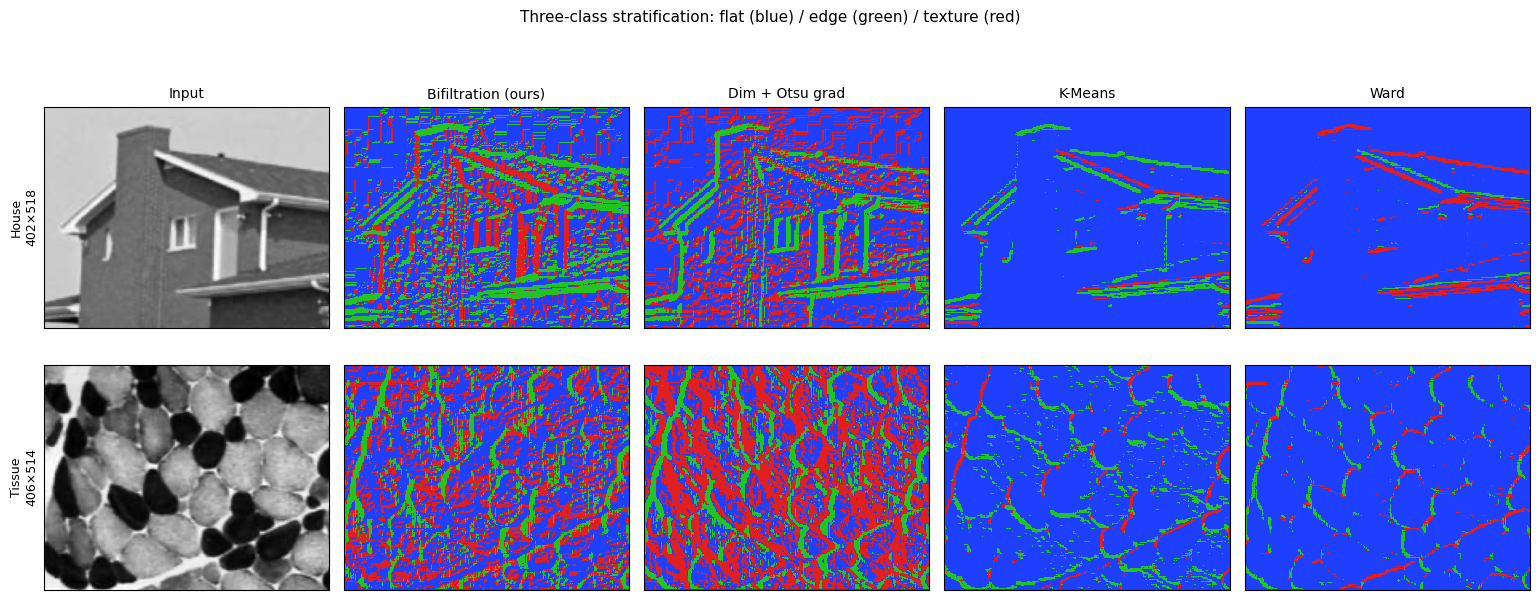

In [ ]:
strat_cmap = ListedColormap(["#1f3fff", "#21c421", "#e02020"])
col_titles = ["Input", "Bifiltration (ours)", "Dim + Otsu grad", "K-Means", "Ward"]
map_keys = ["bif", "dim_otsu", "km", "ward"]

fig, axes = plt.subplots(len(results), 5,
                         figsize=(3.1 * 5, 3.1 * len(results)),
                         squeeze=False)
for r, (name, d) in enumerate(results.items()):
    axes[r, 0].imshow(d["img"], cmap="gray")
    for c, key in enumerate(map_keys, start=1):
        axes[r, c].imshow(d[key], cmap=strat_cmap, vmin=0, vmax=2,
                          interpolation="nearest")
    for c in range(5):
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0:
            axes[r, c].set_title(col_titles[c], fontsize=10)
    axes[r, 0].set_ylabel(f"{name}\n{d['img'].shape[0]}×{d['img'].shape[1]}",
                          fontsize=9)

fig.suptitle("Three-class stratification: flat (blue) / edge (green) / texture (red)",
             fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig(FIG / "patch_stratification.png", dpi=150, bbox_inches="tight")
plt.show()

/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py

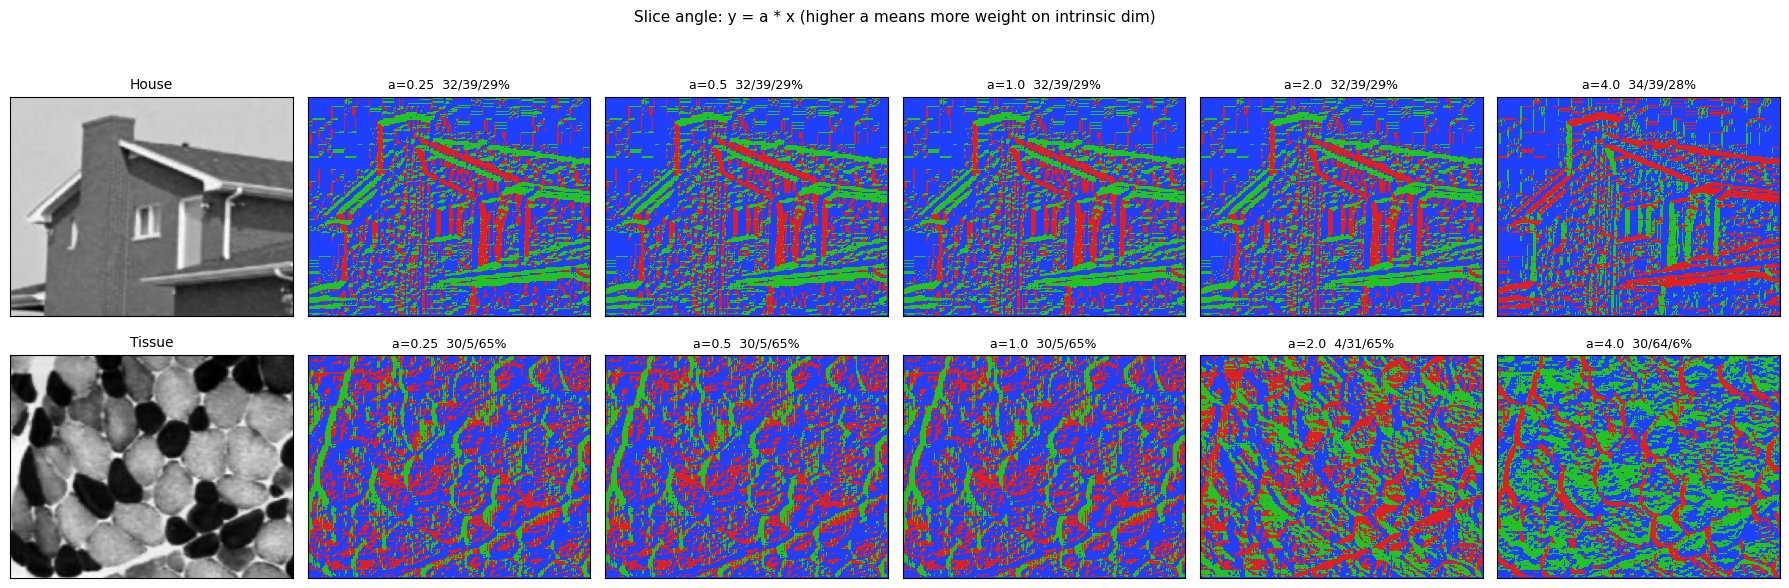

In [7]:
angles = [0.25, 0.5, 1.0, 2.0, 4.0]

fig, axes = plt.subplots(len(results), len(angles) + 1,
                         figsize=(3.0 * (len(angles) + 1), 3.0 * len(results)),
                         squeeze=False)
for r, (name, d) in enumerate(results.items()):
    p = _prep(d["img"], d["cfg"])
    axes[r, 0].imshow(d["img"], cmap="gray")
    axes[r, 0].set_title(name, fontsize=10)
    axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    for c, a in enumerate(angles, start=1):
        lab, _ = _bifilt_labels(p, d["cfg"], _default_pair, a)
        m = _labels_to_map(p, lab)
        pcts, _ = _pcts_dims(lab, p["dims_bif"])
        axes[r, c].imshow(m, cmap=strat_cmap, vmin=0, vmax=2,
                          interpolation="nearest")
        axes[r, c].set_title(f"a={a}  {pcts}%", fontsize=9)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])

fig.suptitle("Slice angle: y = a * x (higher a means more weight on intrinsic dim)",
             fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig(FIG / "patch_slice_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## Filtration-pair sweep

The `Euclid + IntDim(PCA)` default is one choice of two channels. We now rebuild the bifiltration for six
alternative `(f_1, f_2)` pairs to see which geometric features actually
separate the three strata on these images.

`Euclid + IntDim(PCA)`: distance + PCA dimension.

`Euclid + IntDim(MLE)`: Levina–Bickel MLE.

`Euclid + Density`: Gaussian-KDE density as `f_2`.

`Euclid + Tangent`: `1 − |cos(tangent angle)|` between local PCA first components (sensitive to oriented boundaries).

`IntDim + Tangent`: no distance channel at all, pure shape.

`Cosine + IntDim(PCA)`: distance channel is angle-only.

In [8]:
PAIR_FACTORIES = {
    "Euclid + IntDim(PCA)": _default_pair,
    "Euclid + IntDim(MLE)": lambda fb, cfg: (
        fb.get_filtration_from_scipy_dist("euclidean"),
        fb.get_filtration_from_intdim_mle(
            k=min(cfg.k_mle, len(fb.data) - 2),
            flat_percentile=cfg.flat_percentile,
        ),
    ),
    "Euclid + Density": lambda fb, cfg: (
        fb.get_filtration_from_scipy_dist("euclidean"),
        fb.get_filtration_from_density("gaussian", bandwidth=0.3),
    ),
    "Euclid + Tangent": lambda fb, cfg: (
        fb.get_filtration_from_scipy_dist("euclidean"),
        fb.get_filtration_from_tangent_direction(k=cfg.k_nb),
    ),
    "IntDim + Tangent": lambda fb, cfg: (
        fb.get_filtration_from_intrinsic_dim(
            k_neighbors=cfg.k_nb, var_threshold=0.95,
        ),
        fb.get_filtration_from_tangent_direction(k=cfg.k_nb),
    ),
    "Cosine + IntDim(PCA)": lambda fb, cfg: (
        fb.get_filtration_from_scipy_dist("cosine"),
        fb.get_filtration_from_intrinsic_dim(
            k_neighbors=cfg.k_nb, var_threshold=0.95,
        ),
    ),
}

In [9]:
pair_maps = {}
for cfg in CONFIGS:
    img = results[cfg.name]["img"]
    p = _prep(img, cfg)
    pair_maps[cfg.name] = {}
    print(f"=== {cfg.name} ({img.shape}) ===")
    for pair_name, fn in PAIR_FACTORIES.items():
        lab, sms = _bifilt_labels(p, cfg, fn, 1.0)
        pair_maps[cfg.name][pair_name] = _labels_to_map(p, lab)
        pcts, dms = _pcts_dims(lab, p["dims_bif"])
        print(f"{pair_name:26s}  sms={sms:<3}  sizes={pcts}%  dims={dms}")

=== House ((402, 518)) ===


/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py

Euclid + IntDim(PCA)        sms=5    sizes=32/39/29%  dims=1.7/4.9/5.2
Euclid + IntDim(MLE)        sms=10   sizes=33/39/28%  dims=1.2/4.7/6.2
Euclid + Density            sms=10   sizes=43/16/41%  dims=2.8/4.6/5.0


/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py

Euclid + Tangent            sms=15   sizes=28/23/49%  dims=2.2/4.6/4.7


/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py

IntDim + Tangent            sms=5    sizes=32/39/29%  dims=1.7/4.9/5.2


/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/Users/kiruxalight/diploma/new_diploma_2/venv/lib/python3.13/site-packages/sklearn/decomposition/_pca.py

Cosine + IntDim(PCA)        sms=5    sizes=32/39/29%  dims=1.7/4.9/5.2
=== Tissue ((406, 514)) ===
Euclid + IntDim(PCA)        sms=5    sizes=30/5/65%  dims=4.0/4.1/4.2
Euclid + IntDim(MLE)        sms=50   sizes=15/63/21%  dims=2.1/4.2/5.4
Euclid + Density            sms=5    sizes=80/6/14%  dims=4.1/4.2/4.6
Euclid + Tangent            sms=10   sizes=27/54/19%  dims=4.0/4.1/4.3
IntDim + Tangent            sms=50   sizes=30/53/17%  dims=4.0/4.1/4.4
Cosine + IntDim(PCA)        sms=50   sizes=35/37/29%  dims=4.0/4.2/4.2


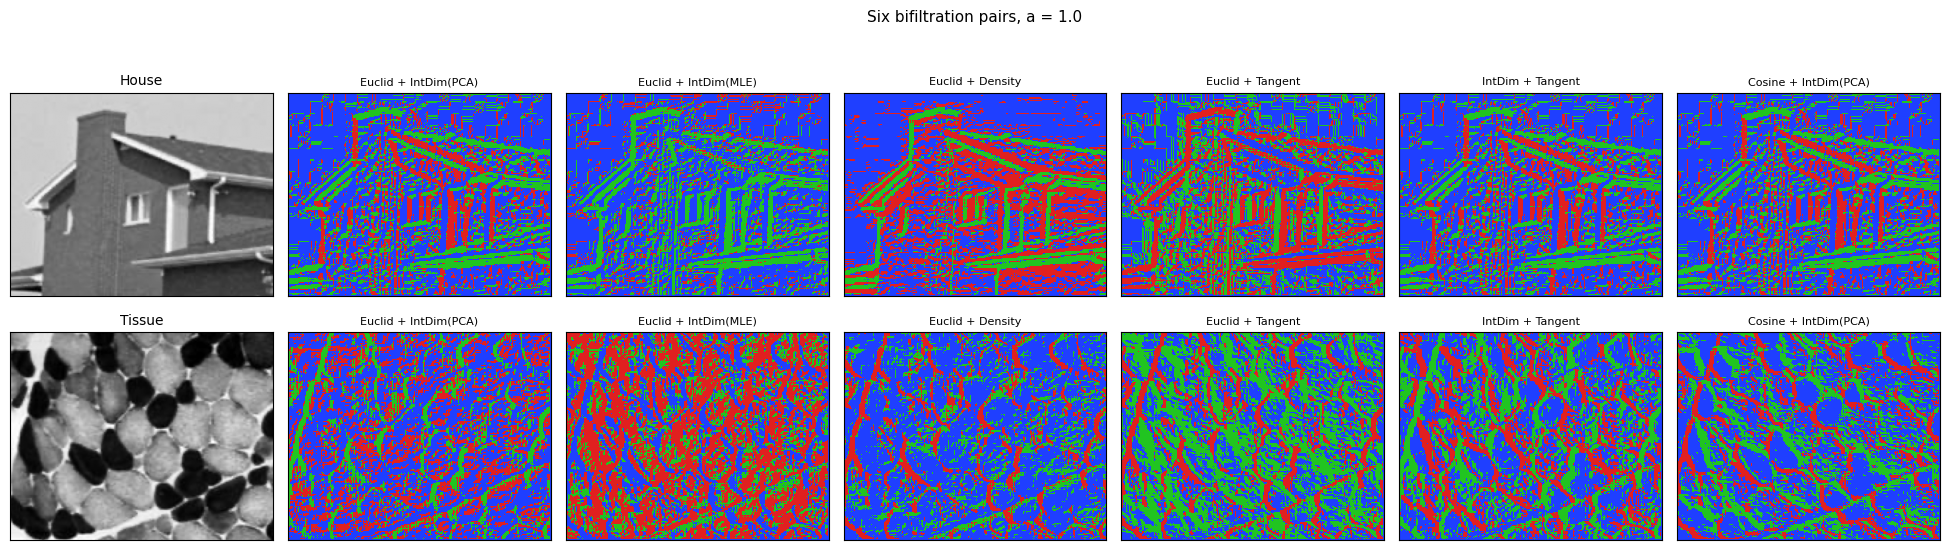

In [11]:
n_pairs = len(PAIR_FACTORIES)
fig, axes = plt.subplots(len(pair_maps), n_pairs + 1,
                         figsize=(2.8 * (n_pairs + 1), 2.8 * len(pair_maps)),
                         squeeze=False)
for r, (name, maps) in enumerate(pair_maps.items()):
    axes[r, 0].imshow(results[name]["img"], cmap="gray")
    axes[r, 0].set_title(name, fontsize=10)
    axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    for c, (pair_name, m) in enumerate(maps.items(), start=1):
        axes[r, c].imshow(m, cmap=strat_cmap, vmin=0, vmax=2,
                          interpolation="nearest")
        axes[r, c].set_title(pair_name, fontsize=8)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])

fig.suptitle("Six bifiltration pairs, a = 1.0",
             fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig(FIG / "patch_pair_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
